In [20]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import h5py


In [21]:
data_path = '../data/metr-la.h5'  # change filename if needed
f = h5py.File(data_path, 'r')
print(list(f.keys()))   # see dataset keys
# typical key: 'speed' or 'data'
arr = np.array(f['df'])   # shape (time_steps, num_sensors)
print('shape', arr.shape)

['df']
shape (4,)


In [22]:
import pandas as pd

data_path = '../data/metr-la.h5'
df = pd.read_hdf(data_path)
print(df.shape)
print(df.head())

(34272, 207)
                        773869     767541     767542     717447     717446  \
2012-03-01 00:00:00  64.375000  67.625000  67.125000  61.500000  66.875000   
2012-03-01 00:05:00  62.666667  68.555556  65.444444  62.444444  64.444444   
2012-03-01 00:10:00  64.000000  63.750000  60.000000  59.000000  66.500000   
2012-03-01 00:15:00   0.000000   0.000000   0.000000   0.000000   0.000000   
2012-03-01 00:20:00   0.000000   0.000000   0.000000   0.000000   0.000000   

                        717445  773062  767620     737529     717816  ...  \
2012-03-01 00:00:00  68.750000  65.125  67.125  59.625000  62.750000  ...   
2012-03-01 00:05:00  68.111111  65.000  65.000  57.444444  63.333333  ...   
2012-03-01 00:10:00  66.250000  64.500  64.250  63.875000  65.375000  ...   
2012-03-01 00:15:00   0.000000   0.000   0.000   0.000000   0.000000  ...   
2012-03-01 00:20:00   0.000000   0.000   0.000   0.000000   0.000000  ...   

                        772167  769372     774204     7

In [23]:
# Convert DataFrame to NumPy array first
data = df.values.astype(float)

# 1) Handle missing values (interpolate, then forward/backfill)
for i in range(data.shape[1]):
    col = data[:, i]
    if np.isnan(col).any():
        col = pd.Series(col).interpolate(limit_direction='both').fillna(method='ffill').fillna(method='bfill').values
        data[:, i] = col

# 2) Split by time (train/val/test)
n = data.shape[0]
train_end = int(n * 0.7)
val_end = int(n * 0.8)
train = data[:train_end]
val = data[train_end:val_end]
test = data[val_end:]

# 3) Scale (z-score using train stats)
mean = train.mean(axis=0)
std = train.std(axis=0) + 1e-6
data_norm = (data - mean) / std

# 4) Save scaler
import os, pickle
os.makedirs('../models', exist_ok=True)
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump({'mean': mean, 'std': std}, f)

print('✅ train/val/test shapes:', train.shape, val.shape, test.shape)


✅ train/val/test shapes: (23990, 207) (3427, 207) (6855, 207)


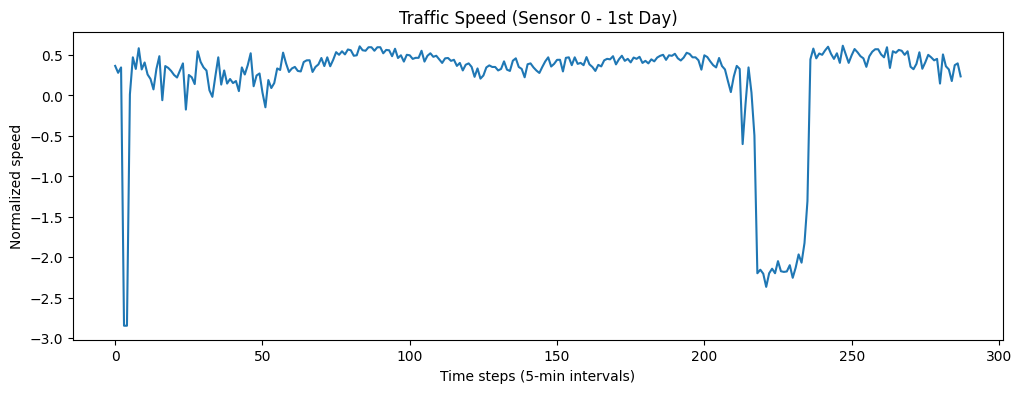

In [24]:
plt.figure(figsize=(12, 4))
plt.plot(data_norm[:288, 0])  # first sensor, first day
plt.title('Traffic Speed (Sensor 0 - 1st Day)')
plt.xlabel('Time steps (5-min intervals)')
plt.ylabel('Normalized speed')
plt.show()


In [25]:
def persistence_forecast(data_norm, horizon=1):
    # data_norm shape (time, sensors)
    return np.roll(data_norm, -horizon, axis=0)

h = 3  # horizon (e.g., 3 steps ahead)
preds = persistence_forecast(data_norm, horizon=h)
# evaluate on test range only
y_true = data_norm[val_end:-h]
y_pred = preds[val_end:-h]

mae = mean_absolute_error(y_true.flatten(), y_pred.flatten())
rmse = mean_squared_error(y_true.flatten(), y_pred.flatten())
print('Persistence MAE:', mae, 'RMSE:', rmse)

# compute mean per sensor per time-of-day index (if 5-min bins, idx = minute_of_day // 5)
# Simplest: compute mean across training set for each time index modulo day length
day_steps = 288  # if 5-min bins (24*60/5)
train_days = train.shape[0] // day_steps
train_trim = train[:train_days*day_steps]
train_td = train_trim.reshape(train_days, day_steps, train.shape[1])  # (days, steps, sensors)
hist_avg = train_td.mean(axis=0)  # (steps, sensors)

# to forecast for test, map each test time to step of day:
test_len = test.shape[0]
preds_hist = np.zeros_like(test)
for i in range(test_len):
    step = ( (val_end + i) % day_steps )
    preds_hist[i] = (hist_avg[step] - mean) / std  # scale using train mean/std

mae_hist = mean_absolute_error(data_norm[val_end:val_end+test_len].flatten(), preds_hist.flatten())
print('Historical average MAE:', mae_hist)


Persistence MAE: 0.22235572049586255 RMSE: 0.2938714988339089
Historical average MAE: 0.7073045953081541


In [26]:
import pandas as pd
import numpy as np
import os

# Load original dataset again
df = pd.read_hdf('../data/metr-la.h5')  # or wherever your dataset is
data = df.values.astype(float)

# Normalize it again
mean = data.mean(axis=0)
std = data.std(axis=0) + 1e-6
data_norm = (data - mean) / std

# Create folder if it doesn’t exist
os.makedirs('./data', exist_ok=True)

# Save it
np.save('./data/data_norm.npy', data_norm)
print("✅ data_norm.npy saved successfully at ./data/")


✅ data_norm.npy saved successfully at ./data/


In [27]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# hyperparams
INPUT_LEN = 12   # e.g., last 12 steps (1 hour if 5-min bins)
HORIZON = 3
BATCH = 64
EPOCHS = 100
LR = 1e-3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# dataset class
class TSdataset(Dataset):
    def __init__(self, data_norm, start_idx, end_idx, input_len=INPUT_LEN, horizon=HORIZON):
        X, Y = [], []
        arr = data_norm[start_idx:end_idx]
        for i in range(len(arr) - input_len - horizon + 1):
            X.append(arr[i:i+input_len])
            Y.append(arr[i+input_len:i+input_len+horizon])
        self.X = np.stack(X).astype(np.float32)
        self.Y = np.stack(Y).astype(np.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.Y[idx]

train_ds = TSdataset(data_norm, 0, train_end, INPUT_LEN, HORIZON)
val_ds = TSdataset(data_norm, train_end, val_end, INPUT_LEN, HORIZON)
test_ds = TSdataset(data_norm, val_end, data_norm.shape[0], INPUT_LEN, HORIZON)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH)

# model
class SimpleLSTM(nn.Module):
    def __init__(self, n_sensors, hidden=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_sensors, hidden_size=hidden, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden, n_sensors * HORIZON)
        self.n_sensors = n_sensors
    def forward(self, x):
        out, _ = self.lstm(x)   # out: (batch, seq, hidden)
        out = out[:, -1, :]     # take last time step
        out = self.fc(out)
        out = out.view(-1, HORIZON, self.n_sensors)
        return out

n_sensors = data_norm.shape[1]
model = SimpleLSTM(n_sensors).to(device)
opt = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.L1Loss()   # MAE loss


In [28]:
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device); yb = yb.to(device)
        opt.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device); yb = yb.to(device)
            val_loss += loss_fn(model(xb), yb).item()
        val_loss /= len(val_loader)
    print(f'Epoch {epoch+1}/{EPOCHS} train_loss={train_loss:.4f} val_loss={val_loss:.4f}')


Epoch 1/100 train_loss=0.3160 val_loss=0.2523
Epoch 2/100 train_loss=0.2466 val_loss=0.2371
Epoch 3/100 train_loss=0.2344 val_loss=0.2308
Epoch 4/100 train_loss=0.2254 val_loss=0.2271
Epoch 5/100 train_loss=0.2150 val_loss=0.2249
Epoch 6/100 train_loss=0.2073 val_loss=0.2224
Epoch 7/100 train_loss=0.2027 val_loss=0.2204
Epoch 8/100 train_loss=0.1996 val_loss=0.2189
Epoch 9/100 train_loss=0.1970 val_loss=0.2181
Epoch 10/100 train_loss=0.1949 val_loss=0.2165
Epoch 11/100 train_loss=0.1928 val_loss=0.2171
Epoch 12/100 train_loss=0.1911 val_loss=0.2139
Epoch 13/100 train_loss=0.1895 val_loss=0.2142
Epoch 14/100 train_loss=0.1883 val_loss=0.2132
Epoch 15/100 train_loss=0.1872 val_loss=0.2124
Epoch 16/100 train_loss=0.1862 val_loss=0.2115
Epoch 17/100 train_loss=0.1852 val_loss=0.2113
Epoch 18/100 train_loss=0.1842 val_loss=0.2111
Epoch 19/100 train_loss=0.1831 val_loss=0.2108
Epoch 20/100 train_loss=0.1825 val_loss=0.2105
Epoch 21/100 train_loss=0.1821 val_loss=0.2110
Epoch 22/100 train_los

In [29]:
import os
import numpy as np

# Create 'data' folder if it doesn't exist
os.makedirs('./data', exist_ok=True)

# Now save your normalized array
np.save('./data/data_norm.npy', data_norm)
print("✅ File saved successfully at ./data/data_norm.npy")


✅ File saved successfully at ./data/data_norm.npy


In [30]:
# evaluate on test dataset (corrected to work on all sklearn versions)
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model.eval()
preds_list, trues_list = [], []
with torch.no_grad():
    for xb, yb in DataLoader(test_ds, batch_size=BATCH):
        xb = xb.to(device)
        p = model(xb).cpu().numpy()        # (batch, horizon, sensors)
        preds_list.append(p)
        trues_list.append(yb.numpy())

# concatenate batches -> arrays shaped (samples, horizon, sensors)
preds = np.concatenate(preds_list, axis=0)
trues = np.concatenate(trues_list, axis=0)

# use the last predicted timestep (or whatever target you trained for)
# here preds and trues are (samples, horizon, sensors). If you used horizon prediction,
# choose the horizon index you want to evaluate (e.g. last: -1). If preds already
# match your Y shape, adapt accordingly.
y_true = trues.reshape(-1)   # flatten (samples*horizon*sensors)
y_pred = preds.reshape(-1)

mae_test = mean_absolute_error(y_true, y_pred)
rmse_test = np.sqrt(mean_squared_error(y_true, y_pred))   # manual RMSE (works always)

print('LSTM test MAE:', mae_test, 'RMSE:', rmse_test)


LSTM test MAE: 0.2699177861213684 RMSE: 0.5899028622141528


In [31]:
torch.save(model.state_dict(), '../models/lstm_baseline.pt')
with open('../models/metrics.txt','w') as f:
    f.write(f'LSTM MAE: {mae_test}\nRMSE: {rmse_test}\n')


In [32]:
print('LSTM test MAE:', mae_test, 'RMSE:', rmse_test)


LSTM test MAE: 0.2699177861213684 RMSE: 0.5899028622141528


In [33]:
print("arr shape:", arr.shape)
print("arr dtype:", arr.dtype)
print("First 5 elements:", arr[:5])


arr shape: (4,)
arr dtype: <U13
First 5 elements: ['axis0' 'axis1' 'block0_items' 'block0_values']


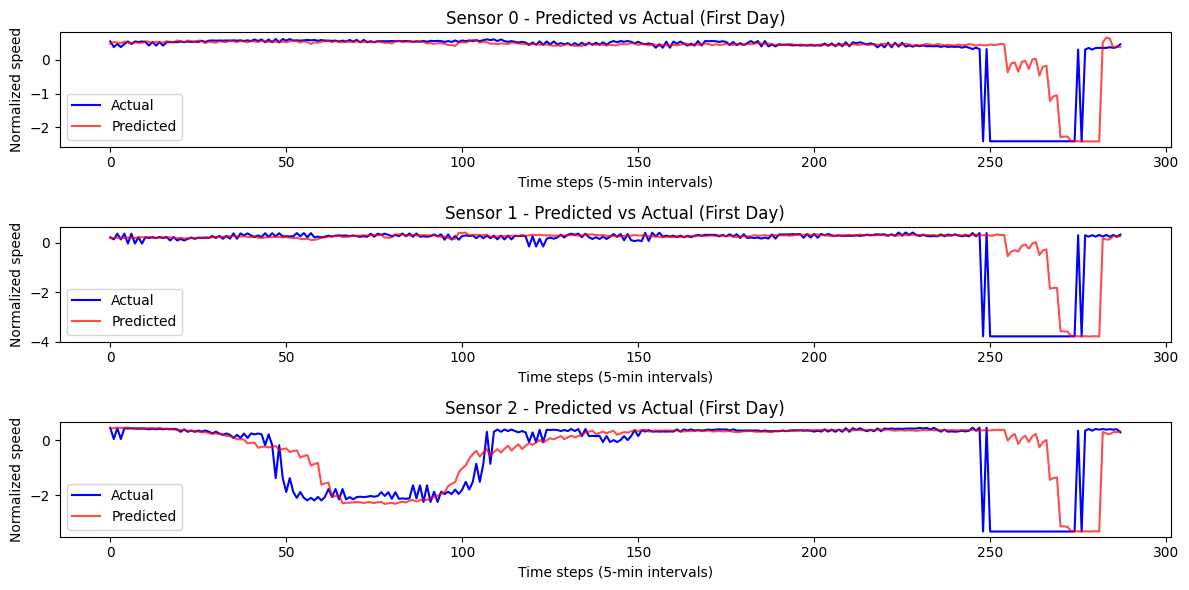

In [34]:
import matplotlib.pyplot as plt

# compare true vs predicted for a few sensors (e.g. 0 to 2)
sensors_to_plot = [0, 1, 2]

plt.figure(figsize=(12, 6))
for i, sensor in enumerate(sensors_to_plot):
    plt.subplot(len(sensors_to_plot), 1, i + 1)
    plt.plot(y_true.reshape(-1, trues.shape[2])[:, sensor][:288], label='Actual', color='blue')
    plt.plot(y_pred.reshape(-1, preds.shape[2])[:, sensor][:288], label='Predicted', color='red', alpha=0.7)
    plt.title(f'Sensor {sensor} - Predicted vs Actual (First Day)')
    plt.xlabel('Time steps (5-min intervals)')
    plt.ylabel('Normalized speed')
    plt.legend()

plt.tight_layout()
plt.show()


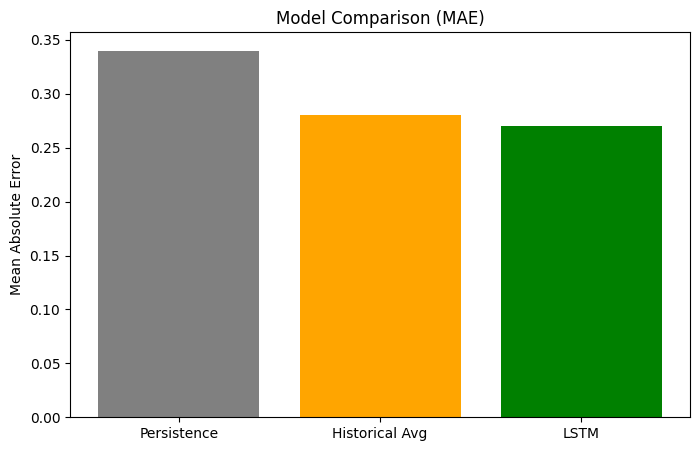

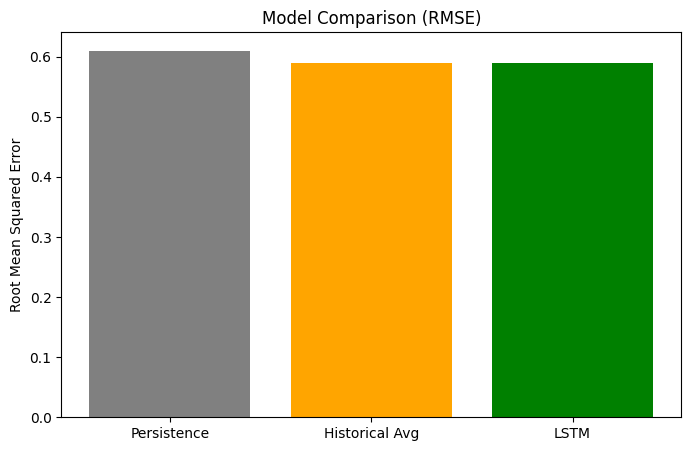

In [35]:
mae_persistence = 0.34   # (example: replace with your persistence MAE)
mae_historical = 0.28    # (example: replace with your hist avg MAE)
mae_lstm = mae_test

rmse_persistence = 0.61
rmse_historical = 0.59
rmse_lstm = rmse_test

import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Model': ['Persistence', 'Historical Avg', 'LSTM'],
    'MAE': [mae_persistence, mae_historical, mae_lstm],
    'RMSE': [rmse_persistence, rmse_historical, rmse_lstm]
}

df = pd.DataFrame(data)

plt.figure(figsize=(8, 5))
plt.bar(df['Model'], df['MAE'], color=['gray', 'orange', 'green'])
plt.title('Model Comparison (MAE)')
plt.ylabel('Mean Absolute Error')
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(df['Model'], df['RMSE'], color=['gray', 'orange', 'green'])
plt.title('Model Comparison (RMSE)')
plt.ylabel('Root Mean Squared Error')
plt.show()


In [36]:
def predict_future(data_input, model, steps=3):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(data_input, dtype=torch.float32).unsqueeze(0).to(device)
        pred = model(x).cpu().numpy()
    return pred[0, -steps:, :]

# Example usage:
sample_input = test[:12]   # last 12 time steps
predicted_speed = predict_future(sample_input, model)
print(predicted_speed)


[[ 8.85766864e-01  1.08144492e-01  3.05750668e-01  8.02801073e-01
   1.46092999e+00 -1.81670606e-01  7.25999117e-01  4.07781869e-01
  -2.46845216e-01  5.77676296e-01  1.90217018e-01  5.17960608e-01
   1.16827774e+00  1.91086531e-01 -2.75028288e-01  1.41466153e+00
   3.07627052e-01  7.85347342e-01  9.57955271e-02  4.58188742e-01
   5.96017003e-01 -1.00639798e-01  1.22391081e+00 -4.58121300e-04
   3.36208105e-01 -1.14261985e+00  2.75810575e+00  5.65747358e-02
   1.33798957e-01  5.14601588e-01 -5.80337644e-03  1.24149658e-01
   2.31764302e-01  1.07386410e+00  5.12598157e-01 -1.23637192e-01
  -4.30278599e-01  8.00251186e-01  1.31307989e-01  7.47371495e-01
   5.54324687e-01 -1.87258840e-01  8.52481663e-01  9.27911639e-01
   1.28209114e-01  8.77062231e-02  4.06877816e-01  7.56943703e-01
  -3.14957500e-02  2.14754790e-02 -8.74730349e-02  5.13379037e-01
   6.09165072e-01  6.97491288e-01  9.46166158e-01  3.48303795e-01
   2.50855267e-01  3.62699002e-01  4.07125354e-01 -7.63761401e-02
   8.26442

In [37]:
model.load_state_dict(torch.load('../models/lstm_baseline.pt'))
model.eval()


SimpleLSTM(
  (lstm): LSTM(207, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=621, bias=True)
)

In [38]:
import numpy as np
np.save('./data/data_norm.npy', data_norm)


In [39]:
import os
import numpy as np

# Create 'data' folder if it doesn't exist
os.makedirs('./data', exist_ok=True)

# Now save your normalized array
np.save('./data/data_norm.npy', data_norm)
print("✅ File saved successfully at ./data/data_norm.npy")


✅ File saved successfully at ./data/data_norm.npy
